# Day 2: Advanced Digital Image Processing (DIP) Techniques
This notebook implements advanced DIP methods for LULC classification, focusing on texture (GLCM, LBP) and shape (HOG) analysis.

In [1]:
import os
import sys
import zipfile
import urllib.request
from pathlib import Path

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    DATA_DIR = Path('/content/data/processed')
    FIGURES_DIR = Path('/content/report/figures')
else:
    DATA_DIR = Path('../data/processed')
    FIGURES_DIR = Path('../report/figures')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# If running in Colab and data not present, download EuroSAT
if IN_COLAB and not DATA_DIR.exists():
    import shutil
    print('Downloading EuroSAT RGB dataset (~90 MB)...')
    url = 'https://madm.dfki.de/files/sentinel/EuroSAT.zip'
    urllib.request.urlretrieve(url, '/content/EuroSAT.zip')
    print('Extracting...')
    with zipfile.ZipFile('/content/EuroSAT.zip', 'r') as z:
        z.extractall('/content/EuroSAT_raw')
    raw_root = Path('/content/EuroSAT_raw/2750')
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for cls_dir in raw_root.iterdir():
        if cls_dir.is_dir():
            shutil.copytree(cls_dir, DATA_DIR / cls_dir.name)
    print('Done! Classes found:', sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()]))
elif not DATA_DIR.exists():
    raise FileNotFoundError('Data directory not found: ' + str(DATA_DIR))
else:
    print('Using DATA_DIR:', DATA_DIR)
    print('Classes found:', sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()]))


Using DATA_DIR: /content/data/processed
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from skimage import exposure



## 1. Texture Analysis: GLCM
Gray-Level Co-occurrence Matrix (GLCM) extracts statistical texture features.

In [3]:
def extract_glcm_features(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    
    return {'contrast': contrast, 'energy': energy, 'homogeneity': homogeneity, 'correlation': correlation}

test_img = list(DATA_DIR.glob('*/*.jpg'))[0]
print(f'GLCM Features for {test_img.parent.name}: {extract_glcm_features(test_img)}')

GLCM Features for Forest: {'contrast': np.float64(4.607142857142857), 'energy': np.float64(0.1526672177132079), 'homogeneity': np.float64(0.47820005279128863), 'correlation': np.float64(0.6455648971482566)}


## 2. Texture Analysis: LBP
Local Binary Patterns (LBP) are powerful for describing local spatial patterns.

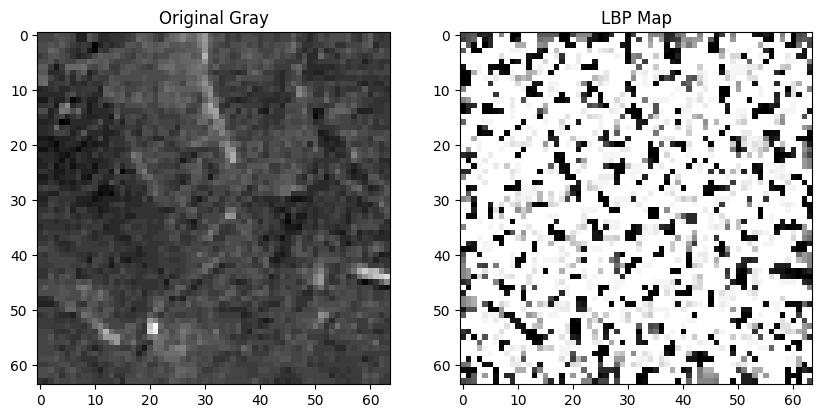

In [4]:
def plot_lbp(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Gray')
    plt.subplot(1, 2, 2); plt.imshow(lbp, cmap='gray'); plt.title('LBP Map')
    plt.show()

plot_lbp(test_img)

## 3. Shape Analysis: HOG
Histogram of Oriented Gradients (HOG) captures edge directions and local shapes.

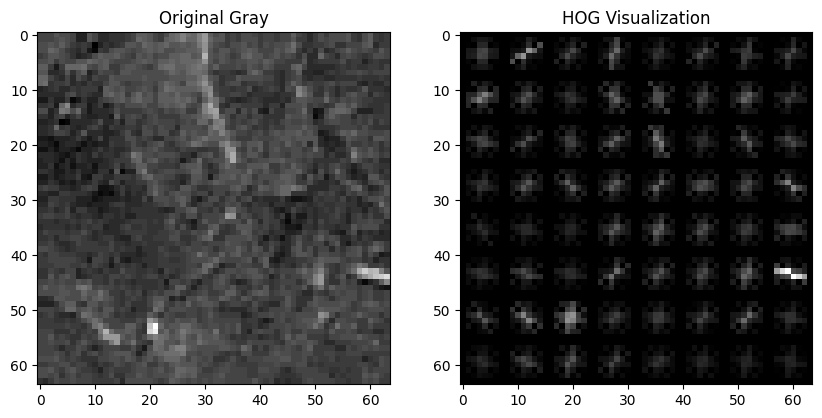

In [5]:
def plot_hog(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    # channel_axis=None is used for grayscale images in newer skimage versions
    fd, hog_image = hog(img, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)
    
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Gray')
    plt.subplot(1, 2, 2); plt.imshow(hog_image_rescaled, cmap='gray'); plt.title('HOG Visualization')
    plt.show()

plot_hog(test_img)